# Project Overview

This project focuses on building a machine learning model to predict loan default using borrower and loan-related information. The dataset has been carefully cleaned and prepared to ensure consistency and reliability.

The approach taken is straightforward and structured: prepare the data, apply appropriate preprocessing techniques, and evaluate a small set of strong classification models. Rather than testing numerous algorithms, the focus is on comparing a few well-established models to identify the most effective approach for this problem.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# Data Loading 
loans_df = pd.read_csv("C:/Users/Rasheedat/Downloads/ML_loans.csv", index_col=0)

In [4]:
# Understanding data
loans_df.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_score,co-applicant_credit_type,age,submission_of_application,loan_to_value,region,security_type,status,debt_to_income,term_category
ID,,,,,,,,,,,,,,,,,,,,,
24890,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,3.99,...,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,Long-term
24891,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.99,...,552,EXP,55-64,to_inst,0.494019,North,direct,1,39.0,Long-term
24892,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,Long-term
24893,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,Long-term
24894,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,Long-term


In [5]:
loans_df.shape

(148670, 32)

In [6]:
loans_df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 148670 entries, 24890 to 173559
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 148670 non-null  object 
 1   gender                     148670 non-null  object 
 2   approv_in_adv              148670 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148670 non-null  object 
 5   credit_worthiness          148670 non-null  object 
 6   open_credit                148670 non-null  object 
 7   business_or_commercial     148670 non-null  object 
 8   loan_amount                148670 non-null  int64  
 9   rate_of_interest           148670 non-null  float64
 10  interest_rate_spread       148670 non-null  float64
 11  upfront_charges            148670 non-null  float64
 12  neg_ammortization          148670 non-null  object 
 13  interest_only              148

# Feature selection and data leakage prevention

Certain variables related to loan pricing and approval decisions (interest_rate_spread, upfront_charges, rate_of_interest, and approv_in_adv) were excluded from the feature set to prevent data leakage. These features may contain information derived after assessing borrower risk, which could lead to unrealistically high model performance.

In [7]:
cols_to_drop = [
    'interest_rate_spread',
    'upfront_charges',
    'rate_of_interest',
    'approv_in_adv'
]

In [8]:
# Defining Features (x) and target(y): The dataset was split into features (X) and target (y), where status represents the loan default outcome.
X = loans_df.drop(['status'] + cols_to_drop, axis=1)
X.shape

(148670, 27)

In [9]:
y = loans_df['status']
y.value_counts()

status
0    112031
1     36639
Name: count, dtype: int64

# Target variable (Status) interpretation

The target variable status represents the loan default outcome, where 1 (Default) indicates a higher-risk group and 0 (Non-default) indicates a lower-risk group. This interpretation is supported by observed differences in key financial metrics, which are income and debt-to-income ratio, across the two groups.

In [10]:
loans_df.groupby('status')[['income', 'debt_to_income']].mean()

,income,debt_to_income
status,,
0,7102.093706,37.483768
1,6214.994678,39.356396


# Train-test Split

The dataset was split into training and testing sets using an 80/20 ratio. Stratified sampling was applied to preserve the distribution of the target variable, and a fixed random state was used to ensure reproducibility.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
X_train.shape, X_test.shape

((118936, 27), (29734, 27))

In [13]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

status
0    0.753548
1    0.246452
Name: proportion, dtype: float64

# Identifying feature types for preprocessing

Features were separated into numerical and categorical variables based on their data types. This distinction is necessary to apply appropriate preprocessing techniques for each group.

In [14]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [15]:
num_cols

Index(['loan_amount', 'property_value', 'income', 'credit_score',
       'loan_to_value', 'debt_to_income'],
      dtype='object')

In [16]:
cat_cols

Index(['loan_limit', 'gender', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'region', 'security_type',
       'term_category'],
      dtype='object')

# Preprocessing Pipeline
A preprocessing pipeline was created using a ColumnTransformer to apply appropriate transformations to different feature types. Numerical variables were scaled, while categorical variables were encoded using one-hot encoding to prepare the data for machine learning models.

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Model Training and Evaluation

Three classification models: Logistic Regression, Random Forest, and XGBoost were trained using a unified pipeline that includes preprocessing and model fitting. A loop-based approach was used to efficiently train, predict, and evaluate each model, with performance metrics stored for comparison.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [19]:
results = []

for name, model in models.items():
    
    # Creating full pipeline (preprocessing + model)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Model selection: XGBoost
Among the models evaluated, XGBoost demonstrated the best overall performance, achieving the highest F1 score and recall. This indicates a strong ability to correctly identify default cases while maintaining a good balance between precision and recall, making it the most suitable model for this task.

In [20]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.868299,0.945198,0.494269,0.649104
1,Random Forest,0.891000,0.928137,0.604531,0.732171
2,XGBoost,0.899543,0.925672,0.644105,0.759636


# Hyperparameter Tuning: XGBoost

Hyperparameter tuning was performed on the best-performing model (XGBoost) to further optimize performance by adjusting key model parameters.

Hyperparameter tuning was attempted on the XGBoost model using a randomized search approach. However, the tuned model did not outperform the default configuration, so the original model was retained as the final model.

In [21]:
param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

In [22]:
XGBoost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

In [23]:
random_search = RandomizedSearchCV(
    XGBoost_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 

In [24]:
best_model = random_search.best_estimator_

In [25]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8962467209255398
Precision: 0.9467256264476732
Recall: 0.6135371179039302
F1 Score: 0.7445557671607187


In [26]:
# The final model (XGBoost) was re-trained separately to generate predictions for detailed evaluation and visualization.
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Confusion matrix

The confusion matrix shows that the model correctly identifies a large number of non-default cases and maintains a low number of false positives. However, some default cases are misclassified as non-default, indicating room for improvement in recall. Overall, the model achieves a strong balance between precision and recall.

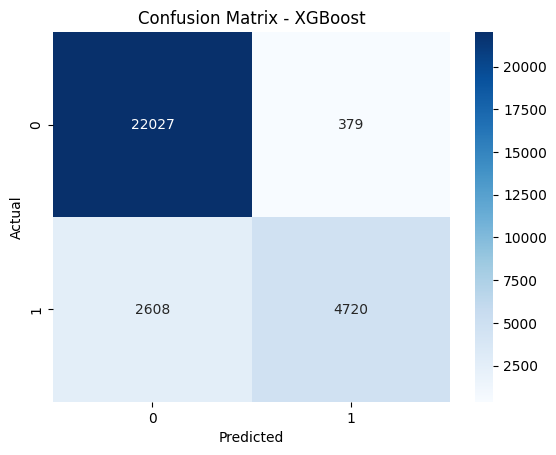

In [27]:
best_pipeline.fit(X_train, y_train)

# Generating predictions
y_pred = best_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# ROC-AUC interpretation

The model achieved a ROC-AUC score of 0.89, indicating a strong ability to distinguish between default and non-default cases. This, combined with a solid F1 score and high precision, demonstrates that the model performs well in identifying high-risk borrowers while maintaining overall prediction reliability.

In [28]:
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8903035728450388


# ROC Curve interpretation
The ROC curve demonstrates strong model performance, with the curve significantly above the diagonal baseline. The model achieves a high true positive rate at relatively low false positive rates, and an AUC score of 0.89 indicates strong discriminatory power between default and non-default cases.

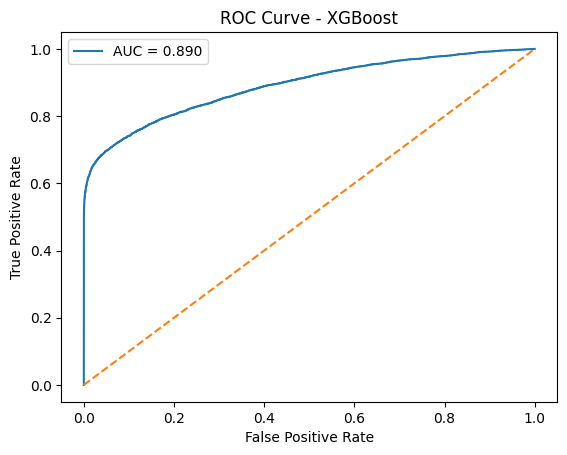

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

# Feature Importance interpretation

Feature importance analysis revealed that credit_type_EQUI is the most influential variable in predicting loan default, contributing significantly more than other features. Other important predictors include loan structure characteristics and borrower risk indicators such as debt-to-income ratio, credit_worthiness, and loan type. These results align with financial intuition, as both borrower capacity and loan conditions play key roles in default risk.

The variable credit_type_EQUI represents whether a loan is equity-based. Its high importance suggests that the model strongly differentiates between equity-backed loans and other types of credit, which is consistent with financial intuition, as secured loans typically exhibit different risk profiles compared to unsecured loans. However, the unusually large feature importance (≈ 0.79) raised concerns about possible feature redundancy or excessive model dependence on a single predictor. As a result, further robustness testing and feature validation experiments were identified as important areas for future model refinement.
```


In [30]:
# Get feature names after preprocessing
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importance from XGBoost
importances = best_pipeline.named_steps['model'].feature_importances_

# Creating  DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
44,cat__credit_type_EQUI,0.790438
29,cat__lump_sum_payment_lpsm,0.036618
25,cat__neg_ammortization_neg_amm,0.018861
19,cat__credit_worthiness_l1,0.016439
12,cat__loan_type_type1,0.016315
55,cat__submission_of_application_not_inst,0.011496
17,cat__loan_purpose_p3,0.006897
5,num__debt_to_income,0.006061
14,cat__loan_type_type3,0.006025
15,cat__loan_purpose_p1,0.005955


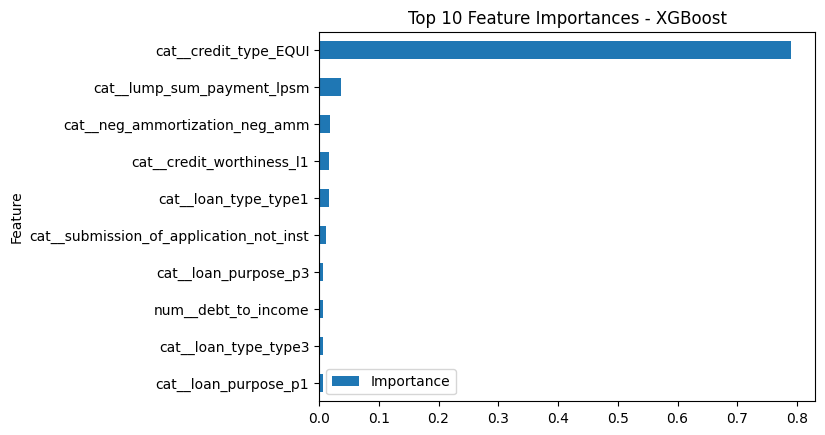

In [31]:
# Visualizing feature importance
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - XGBoost')
plt.show()

# Conclusion

This project developed a machine learning model to predict loan defaults based on borrower and loan characteristics. After thorough data cleaning and preprocessing, features likely to introduce data leakage were identified and removed to better reflect model performance.

Three models: Logistic Regression, Random Forest, and XGBoost were trained and evaluated using a consistent pipeline. Among them, XGBoost achieved the strongest overall performance, with solid precision, recall, and F1-score results, indicating a good balance between correctly identifying defaulters and minimizing false predictions.

Hyperparameter tuning was explored but did not significantly improve performance, so the default XGBoost model was retained. Additional evaluation using confusion matrices and ROC-AUC analysis confirmed the model’s strong ability to distinguish between default and non-default cases.

During feature importance analysis, the `credit_type` variable displayed unusually strong influence on model predictions (feature importance ≈ 0.79). This raised concerns about potential feature redundancy or excessive model dependence on a single predictor. To investigate this further, additional robustness testing was conducted by retraining the model without the feature and comparing performance metrics and feature importance distributions.

Future model refinements and validation experiments will be conducted to further investigate and address these discrepancies.